<a href="https://colab.research.google.com/github/ga4gh/analytics-dashboard/blob/develop/notebooks/Analytics_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analytics Dashboard Overview

This notebook provides a proof of concept for a comprehensive analytics dashboard for exploring GA4GH impact. We will use community feedback to iterate on the design and metrics captured here, and will surface enhancements into a final dashboard which will be hosted on the GA4GH website.

If you have ideas for improvements on the key visualisations or metrics shown here, please create an issue directly into the GA4GH Analytics Dashboard repo that describes what you'd like to see on the final dashboard. The website dashboard will be showcased at Connect 2026, so please **contribute your views by January 15th 2026**.

## What This Notebook Does

This notebook is designed to do three things:
1. **Fetches** data from a new GA4GH Tech Team database that contains the following:
     - **GA4GH-managed GitHub repositories**.  Currently this is representing repos belonging to the GA4GH Github Organisation only (including both GA4GH standards and implementations). This does NOT include external implementations or GA4GH standards that are managed outside the organisation.
     - **PyPi libraries**. Based on a query of the PyPi API that searches for "GA4GH" and was subsequently manually curated to include the following:
        - Packages that come from GA4GH directly (standards)
        - Packages that utilise GA4GH standards (GA4GH as well as external implementations)
     - **Pubmed articles**. Based on a query of the Pubmed API that searches for either "GA4GH" or "Global Alliance for Genomics and Health" which omits entries that refer to a publication correction (erratum), or preprints, as these lead to frequent duplicate entries for the same publication.
1. **Analyzes the data** to compute simple statistics and insights on the three above listed data types.
1. **Creates interactive visualizations** to graphically represent trends in the data.

## How to Run This Notebook on Google Colab (no installation required)

1. **Click the "Open in Colab" button** at the very top of this notebook
1. **Click "Run All"** to execute the full notebook end to end
1. **Wait for results** as it might take a couple of minutes for the notebook to fetch the data and create the analytics
1. **Scroll through the results** - Each section provides different insights

## Explore use cases

1. *TBC*
1. *TBC*
1. *TBC*

## Useful information on data sourcing

Directly querying the APIs of the three data sources can lead to a number of unpredictable issues, including reaching a quota limit, servers not responding, and changes to the API and the data they provide. To circumvent these issues and guarantee a stable and uniform access to data, the tech team has curated data from the three sources (currently: GitHub, Pypi and Pubmed) and stored them in a database hosted on AWS. Data are then fetched in this notebook via a unified set of APIs, described in more detail [here]('Analytics_Dashboard_Technical_Documentation.ipynb').

<font color='red' size=4>
Data in this current notebook version were last fetched between <b>1st October</b> (GitHub and PyPi) and <b>1st December</b> (PubMed) <b>2025</b>.
</font>

## What you can customize

- Can modify visualization types, styling, and data presented
- Requires knowledge of Plotly and Dash libraries

## How you can contribute

Suggest any change or feedback _here - TBD_, for example
- other ways to analyse, present, or interpret the data
- data and insights you might want to see in the future
- different or additional query terms for PubMed

## What's next on the roadmap
- switch from Pubmed to Europe PMC, which also provides data on preprints, grants, etc
- ...
- incorporate your ideas!
   
### Important notes

- **Processing time** - Initial run may take 2-3 minutes
- **Internet required** - Fetches data from API set up by the tech team
- **No data storage** - Results are temporary unless you save them

### Troubleshooting

**If visualizations don't appear:**
1. Ensure you have the required libraries installed
1. Try refreshing your browser
1. Check that JavaScript is enabled

**If results seem incomplete:**  
1. Try running individual sections instead of all at once

***Note: This is not a complete dataset. This is a POC and will be more complete in the future***



## Libraries required in this notebook

- `dash`: Used to build interactive dashboard components such as graphs, layouts, and user inputs directly inside the notebook.
- `requests`: Connects to the Analytics Dashboard DB which is curated by the Tech Team and retrieves data in JSON format.
- `pandas`: Helps convert API responses into DataFrames for easy filtering, analysis, and visualization.
- `numpy`: For numerical operations and array/matrix manipulation
- `json`: Used for handling and inspecting raw JSON responses.
- `typing` (List, Optional, Dict, Any): Adds optional type hints to improve code readability and maintainability.
- `plotly.express`: Creates interactive charts (bar, line, pie, scatter) quickly and easily.

These libraries are widely used and are usually already present by default on Google Colab, with the exception of `dash`, which we will need to make sure is installed before proceeding to running the rest of this notebook.

First, we install the `dash` package.

In [122]:
!pip install dash


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


Now that `dash` is installed, we can load all the rest of the packages we need for this notebook.

In [123]:
import requests
import json
import dash
from typing import List, Optional, Dict, Any
from dash import Dash, dcc, html, Input, Output, callback, dash_table, jupyter_dash
from dash.dependencies import Input, Output
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
from collections import Counter
from datetime import datetime
import numpy as np

## Setup and configurations

There are several API endpoints available for the dashboard and details are provided [here]('Analytics_Dashboard_Technical_Documentation.ipynb'). Each of the three data sources has one or more endpoints, serving specific slices or views of the data. All of them return a JSON payload.

Here we will declare some utility functions and variables that later on will be used to access the data.

In [124]:
# Base URL
BASE_URL = "http://analytics-staging.ga4gh.org:8000"

# Github Endpoints
REPO_ENDPOINT = f"{BASE_URL}/github/name/" # fetches repo based on repo name parameter provided by user after name/
REPO_OWNER_ENPOINT = f"{BASE_URL}/github/owner/" # fetches repos based on repo owner parameter provided user after owner/
ALL_REPOS_ENDPOINT = f"{BASE_URL}/github/all"

# PyPi Endpoints
TOTAL_PACKAGES_ENDPOINT = f"{BASE_URL}/pypi/total-packages"
PACKAGE_VERSIONS_ENDPOINT = f"{BASE_URL}/pypi/package-versions"
RELEASES_OVER_YEARS_ENDPOINT = f"{BASE_URL}/pypi/releases-over-years"
PYPI_DETAILS_ENDPOINT = f"{BASE_URL}/pypi/project-details"
FIRST_RELEASES_ENDPOINT = f"{BASE_URL}/pypi/first-releases"
ALL_PACKAGES_ENDPOINT = f"{BASE_URL}/pypi/all-packages"

# PubMed Endpoints
PM_KEYWORD = f"{BASE_URL}/pubmed/articles/GA4GH"

# Function that will take a list of repos and retrieve them from the DB
def get_repos(endpoint: str, list_of_repos: List[str]) -> List[Dict[str, Any]]:

    items: List[Dict[str, Any]] = []
    url = endpoint

    for repo in list_of_repos:
        resp = requests.get(url + repo)
        resp.raise_for_status()
        items.append(resp.json()[0])

    return items

# Function to make a request to the endpoints to return data from the DB addressing any pagination issues
def get_json(endpoint: str, token: Optional[str] = None, per_page: int = 100) -> List[Dict[str, Any]]:

    headers = {}
    if token:
        headers["Authorization"] = f"token {token}"

    params = {"per_page": per_page, "page": 1}
    items: List[Dict[str, Any]] = []
    url = endpoint

    while True:
        resp = requests.get(url, headers=headers, params=params, timeout=30)
        resp.raise_for_status()
        data = resp.json()

        if not isinstance(data, list):
            return data

        items.extend(data)

        if "next" in resp.links:
            url = resp.links["next"]["url"]
            params = None
        else:
            break

    return items


def get_last_year(dates):
    last_year = [] 
    for d in dates:
        if hasattr(d, "year"):
            y = d.year
        else:
            y = datetime.fromisoformat(d).year
        if y == 2025:
            last_year.append(d)
    return last_year

We can now access the data and load the returned JSON file into a pandas DataFrame, for simplicity of use later on.

In [125]:
#PubMed
pubmed_json = get_json(PM_KEYWORD)
pm_df = pd.DataFrame.from_records(pubmed_json)
pm_df['publish_date'] = pd.to_datetime(pm_df['publish_date'], utc=True, errors='raise')
pm_df['year'] = pm_df['publish_date'].dt.year
pm_last_year = get_last_year(pm_df['publish_date'])

# GitHub
GA4GH_json = get_json(ALL_REPOS_ENDPOINT)
gh_df = pd.DataFrame.from_records(GA4GH_json)
gh_df['last_updated'] = pd.to_datetime(gh_df['last_updated'], utc=True, errors='raise')
gh_df['pushed_at'] = pd.to_datetime(gh_df['pushed_at'], utc=True, errors='raise')
gh_df['created_on'] = pd.to_datetime(gh_df['created_on'], utc=True, errors='raise')
gh_last_year = get_last_year(gh_df['created_on'])

# PyPi
pypi_packages_json = get_json(PYPI_DETAILS_ENDPOINT)
pypi_df = pd.DataFrame.from_records(pypi_packages_json)

pypi_first_versions_df = pd.DataFrame.from_records(get_json(FIRST_RELEASES_ENDPOINT))

pypi_df = pypi_df.merge(pypi_first_versions_df,how='inner',on='project_name')
assert pypi_df.shape[0] == int(get_json(TOTAL_PACKAGES_ENDPOINT).get("total_packages", 0))
pypi_df['first_release'] = pd.to_datetime(pypi_df['release_date'], utc=True, errors='raise')

pypi_last_year = get_last_year(pypi_df['first_release'])

## Total impact
Time for the first analytics: how many papers, repos, and packages have been released so far across the organisation and in the last year?

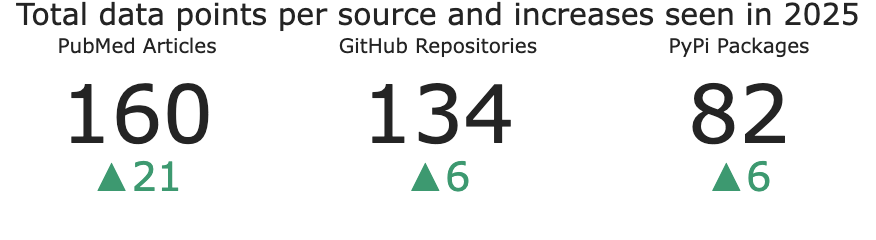

In [126]:
def plot_indicators():
    
    fig = go.Figure()
    
    fig = make_subplots(
        rows=1, cols=3,
        specs=[[{"type": "indicator"}, {"type": "indicator"}, {"type": "indicator"}]],
        horizontal_spacing=0.08
    )
    
    fig.add_trace(
        go.Indicator(mode="number+delta", value=pm_df.shape[0], title={"text": "PubMed Articles"}, delta={"reference": pm_df.shape[0] - len(pm_last_year)}),
        row=1, col=1
    )
    fig.add_trace(
        go.Indicator(mode="number+delta", value=gh_df.shape[0], title={"text": "GitHub Repositories"}, delta={"reference": gh_df.shape[0] - len(gh_last_year)}),
        row=1, col=2
    )
    fig.add_trace(
        go.Indicator(mode="number+delta", value=pypi_df.shape[0], title={"text": "PyPi Packages"}, delta={"reference": pypi_df.shape[0] - len(pypi_last_year)}),
        row=1, col=3
    )
    
    fig.update_layout(
        template="simple_white",
        title={
            "text": "Total data points per source and increases seen in 2025\n",
            "x": 0.5,
            "xanchor": "center",
            "font": {"size": 30},
            "pad": {"b": 40},
        },
        margin=dict(l=20, r=20, t=50, b=20),
        height=240
    )
    fig.show()
plot_indicators()

*Here comment on global impact*

Now we look at the distribution over time:

In [127]:
to_combine_pm_df = pd.DataFrame({'item': pm_df['title'],
                                 'year': pm_df['year'],
                                 'Source': 'PubMed Articles'})

to_combine_gh_df = pd.DataFrame({'item': gh_df['name'],
                                 'year': gh_df['created_on'].dt.year,
                                 'Source': 'GitHub Repos'})

to_combine_pypi_df = pd.DataFrame({'item': pypi_df['project_name'],
                                   'year': pypi_df['first_release'].dt.year,
                                   'Source': 'PyPi Packages'})

combined_year_df = pd.concat([to_combine_pm_df,to_combine_gh_df,to_combine_pypi_df])

In [128]:
# Group by Year and Source
year_plot_df = combined_year_df.groupby(['year', 'Source']).agg({'item': list}).reset_index()
year_plot_df = year_plot_df.sort_values(['Source', 'year'])

# List items and calculate cumulative sum
year_plot_df['items_str'] = year_plot_df['item'].apply(lambda items: '<br>'.join(items))
year_plot_df['yearly_count'] = year_plot_df['item'].apply(len)
year_plot_df['yearly_cumulative_count'] = year_plot_df.groupby(['Source'])['yearly_count'].cumsum()

Time to generate the figure

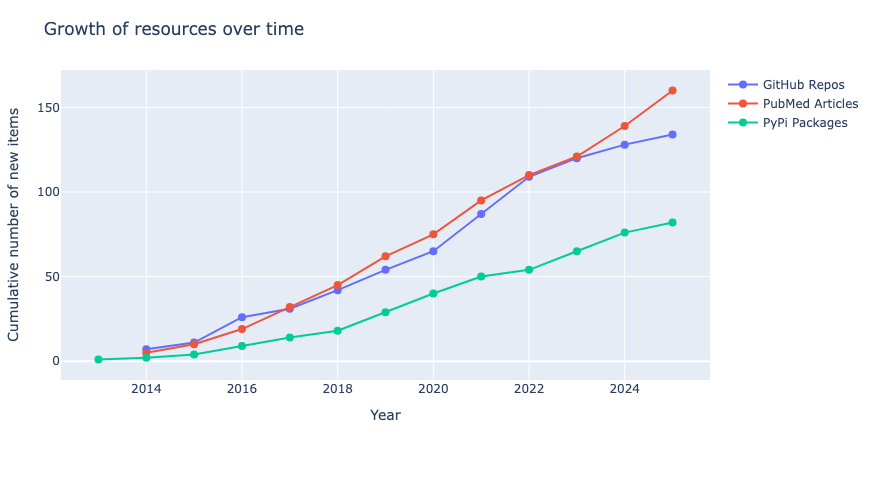

In [129]:
def plot_year():
    fig = px.line(
        year_plot_df,
        x='year',
        y='yearly_cumulative_count',
        color='Source',
        markers=True,
        title='Growth of resources over time',
        labels={'year': 'Year', 'yearly_cumulative_count': 'Total to date'},
        custom_data=['items_str', 'Source', 'yearly_count']
    )
    
    # 5. Update Hover Template
    fig.update_traces(
        hovertemplate=(
            '<b>%{customdata[1]}</b><br>' # Source Name
            'Year: %{x}<br>'
            'Number of new items: %{customdata[2]}<br><br>'
            '<b>New Items:</b><br>%{customdata[0]}<extra></extra>'
        ),
        marker=dict(size=8),
    )
    
    fig.update_layout(
        xaxis_title='Year',
        yaxis_title='Cumulative number of new items',
        margin=dict(l=40, r=20, t=70, b=120),
        height=500,
        legend_title_text=''
    )
    fig.show()
plot_year()

## PubMed

In [130]:
articles_in_top = []

for j, g in pm_df.groupby('journal'):
    titles_sorted = g.sort_values('title')
    details = "<br>".join(r['title'] for _, r in titles_sorted.iterrows())
    articles_in_top.append({'journal': j, 'Count': len(g), 'Details': details})

top_journals = pd.DataFrame(articles_in_top).sort_values('Count', ascending=False).head(10).reset_index(drop=True)

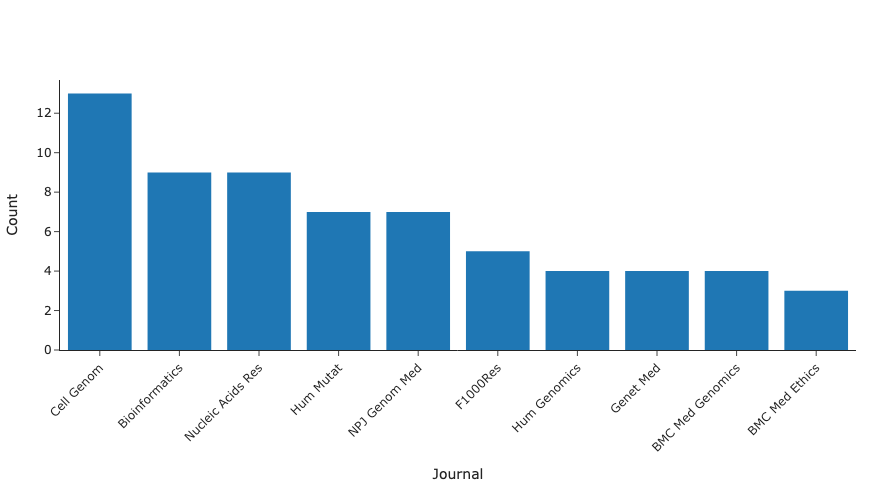

In [255]:
def plot_top_journals():
    
    if isinstance(top_journals, pd.Series):
        df = top_journals.reset_index()
        df.columns = ["journal", "Count"]
    else:
        df = top_journals.copy()

    df = df.sort_values("Count", ascending=False).reset_index(drop=True)

    # build customdata for hover (Count + Details if available)
    if "Details" in df.columns:
        customdata = df[["Count", "Details"]].values
        hovertemplate = "Count: %{customdata[0]}<br>%{customdata[1]}<extra></extra>"
    else:
        customdata = df[["Count"]].values
        hovertemplate = "Count: %{customdata[0]}<extra></extra>"

    fig = go.Figure(
        go.Bar(
            x=df["journal"],
            y=df["Count"],
            #marker_color=colors,
            customdata=customdata,
            hovertemplate=hovertemplate,
            marker_line_width=0,
        )
    )

    fig.update_layout(
        barmode="relative",
        xaxis_tickangle=-45,
        margin=dict(l=40, r=20, t=80, b=150),
        xaxis_title="Journal",
        yaxis_title="Count",
        legend_title_text="",
        height=500,
        template="simple_white",
    )

    fig.show()
plot_top_journals()

## GitHub

In [135]:
fetch_date = '2025-10-01'
target_date = pd.to_datetime(fetch_date, utc=True)

gh_df['days_since_pushed_at'] = (target_date - gh_df['pushed_at']).dt.days
gh_df['days_since_last_updated'] = (target_date - gh_df['last_updated']).dt.days

gh_df['activity_score'] = 1/(1+gh_df['days_since_pushed_at']) + 1/(1+gh_df['days_since_last_updated'])

gh_activity_df = gh_df.sort_values('activity_score', ascending=False).head(15).reset_index(drop=True)

In [136]:
conditions = [
    (gh_df['is_archived'] == False) & (gh_df['days_since_pushed_at'] < 180),
    (gh_df['is_archived'] == False) & (gh_df['days_since_pushed_at'] >= 180) & (gh_df['days_since_pushed_at'] <= 365),
    (gh_df['is_archived'] == False) & (gh_df['days_since_pushed_at'] > 365),
    (gh_df['is_archived'] == True)
]
choices = ['Active', 'Low Activity', 'Inactive', 'Archived']

gh_df['activity_status'] = np.select(conditions, choices, default='Unknown')

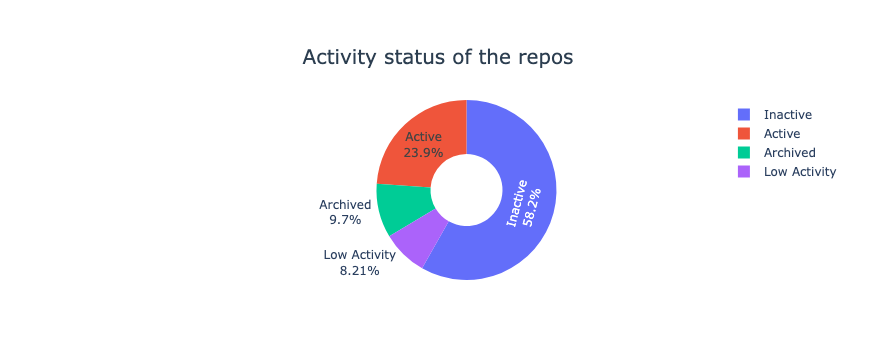

In [137]:
gh_activity_counts = gh_df['activity_status'].value_counts().reset_index()
gh_activity_counts.columns = ["Category", "Count"]

def plot_github_status():
        
    fig = go.Figure(data=[
        go.Pie(
            labels=gh_activity_counts["Category"],
            values=gh_activity_counts["Count"],
            hole=0.4,
            textinfo="label+percent",
            hoverinfo="label+value+percent"
        )
    ])
    
    fig.update_layout(
        title={
            "text": "Activity status of the repos",
            "x": 0.5,          # center title
            "xanchor": "center",
            "yanchor": "top",
            "font": {"size": 20, "color": "#2C3E50"}
        },
        plot_bgcolor="#f9f9f9",
        paper_bgcolor="#ffffff"
    )

    fig.show()
plot_github_status()

In [141]:
gh_df['total_interest'] = gh_df['subscribers_count'] + gh_df['stargazers_count'] + gh_df['forks_count']
gh_interest_df = gh_df.sort_values('total_interest', ascending=False).head(10).reset_index(drop=True)

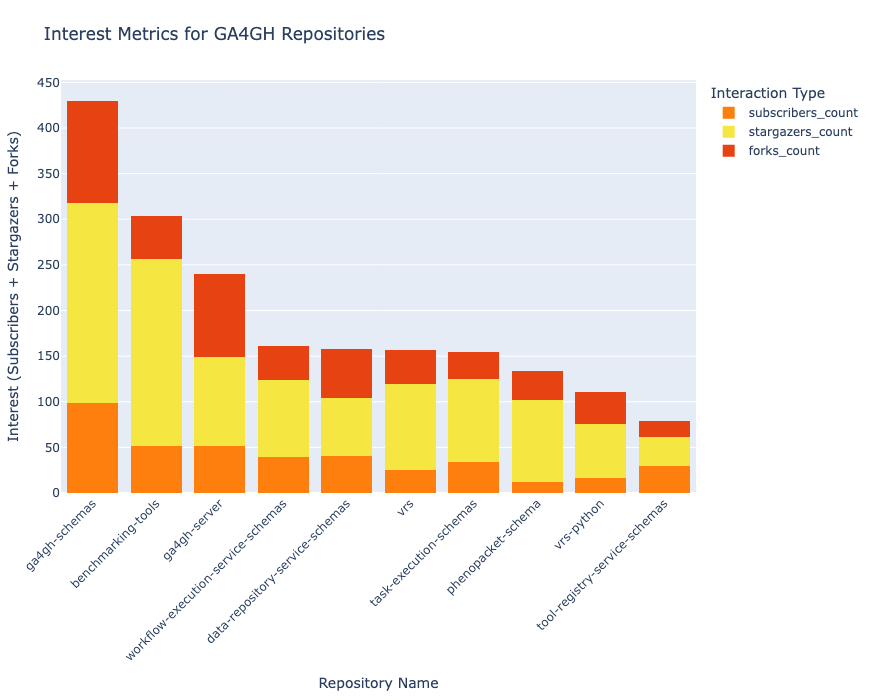

In [142]:
def plot_gh_interest():
    fig = px.bar(
        gh_interest_df,
        x='name',
        y=['subscribers_count','stargazers_count','forks_count'],
        #labels={'Count': 'total_interest', 'repo': 'asda'},
        title='Interest Metrics for GA4GH Repositories',
        color_discrete_sequence=['#ff7f0e', '#f5e642', '#e64212'],
    )
    
    fig.update_layout(
        barmode='stack',
        xaxis_tickangle=-45,
        margin=dict(l=40, r=20, t=80, b=150),
        xaxis_title='Repository Name',
        yaxis_title='Interest (Subscribers + Stargazers + Forks)',
        legend_title_text='Interaction Type',
        height = 700
    )
    
    fig.update_traces(marker_line_width=0)
    
    fig.show()
plot_gh_interest()

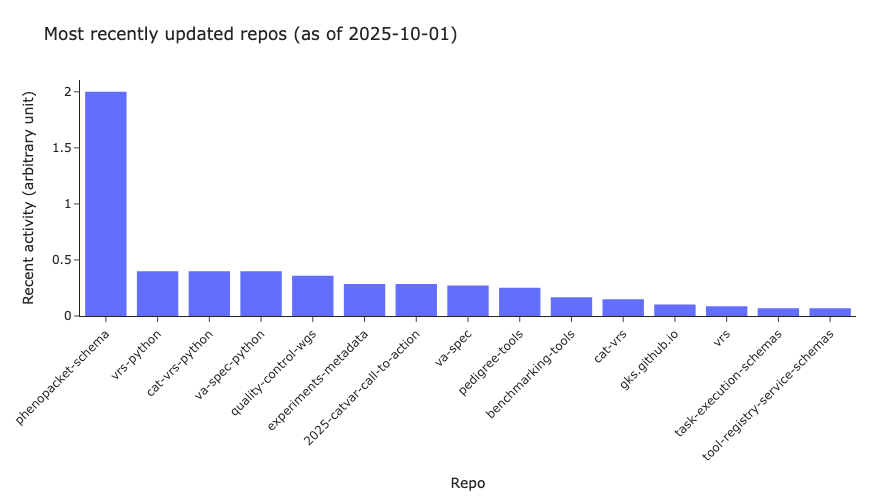

In [256]:
def plot_gh_activity():
    fig = px.bar(
        gh_activity_df,
        x='name',
        y='activity_score',
        labels={'activity_score': 'Count', 'name': 'Repo'},
        title=f'Most recently updated repos (as of {fetch_date})',
        #color_discrete_sequence=['#f5e642'],
        custom_data=['days_since_pushed_at', 'days_since_last_updated'],
    )
    
    fig.update_traces(
        hovertemplate='Days since last commit: %{customdata[0]}<br>Days since last repo update: %{customdata[1]}<extra></extra>',
        marker_line_width=0
    )
    
    fig.update_layout(
        barmode='relative',
        xaxis_tickangle=-45,
        margin=dict(l=40, r=20, t=80, b=150),
        xaxis_title='Repo',
        yaxis_title='Recent activity (arbitrary unit)',
        legend_title_text='',
        height=500,
        template='simple_white',
    )
    
    fig.show()

plot_gh_activity()

## PyPi

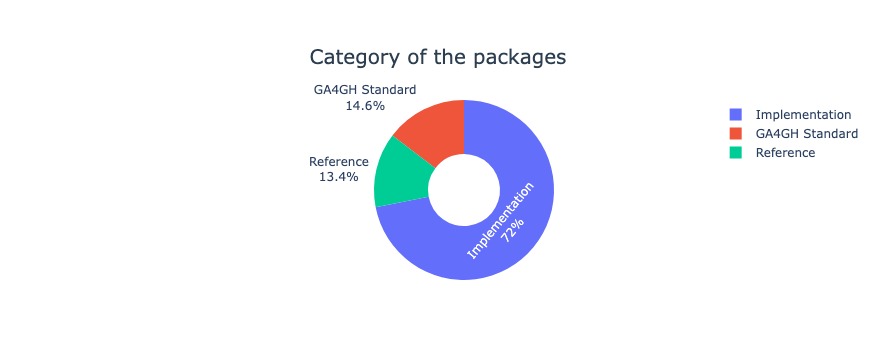

In [148]:
pypi_type_counts = pypi_df['category'].value_counts().reset_index()
pypi_type_counts.columns = ["Category", "Count"]

def plot_pypi_status():
        
    fig = go.Figure(data=[
        go.Pie(
            labels=pypi_type_counts["Category"],
            values=pypi_type_counts["Count"],
            hole=0.4,
            textinfo="label+percent",
            hoverinfo="label+value+percent"
        )
    ])
    
    fig.update_layout(
        title={
            "text": "Category of the packages",
            "x": 0.5,          # center title
            "xanchor": "center",
            "yanchor": "top",
            "font": {"size": 20, "color": "#2C3E50"}
        },
        plot_bgcolor="#f9f9f9",
        paper_bgcolor="#ffffff"
    )

    fig.show()
plot_pypi_status()

In [149]:
pypi_all_versions_json = get_json(ALL_PACKAGES_ENDPOINT)

In [250]:
rows_list = []

for ver in pypi_all_versions_json:
    dict1 = {'package': ver['package']['project_name'],
             'package_version': ver['version']['package_version'],
             'release_date': pd.to_datetime(ver['version']['release_date'], utc=True, errors='raise'),
             'category': ver['package']['category']
            }
 
    rows_list.append(dict1)
    
pypi_all_versions_df = pd.DataFrame(rows_list)

In [251]:
pypi_all_versions_df = pypi_all_versions_df.sort_values(['package','release_date','category']).reset_index(drop=True)
pypi_release_range_df = pypi_all_versions_df.groupby('package')['release_date'].agg(['first','last','count'])
pypi_release_range_df['range_days'] = (pypi_release_range_df['last']-pypi_release_range_df['first']).dt.days
pypi_release_range_df['frequency_year'] = (pypi_release_range_df['count']/pypi_release_range_df['range_days'])*365
category_per_package = pypi_all_versions_df.groupby('package')['category'].first()
pypi_release_range_df = pypi_release_range_df.join(category_per_package)
pypi_release_range_df['first'] = pypi_release_range_df['first'].dt.strftime('%Y-%m-%d')
pypi_release_range_df['last'] = pypi_release_range_df['last'].dt.strftime('%Y-%m-%d')

pypi_release_range_df = pypi_release_range_df.reset_index()

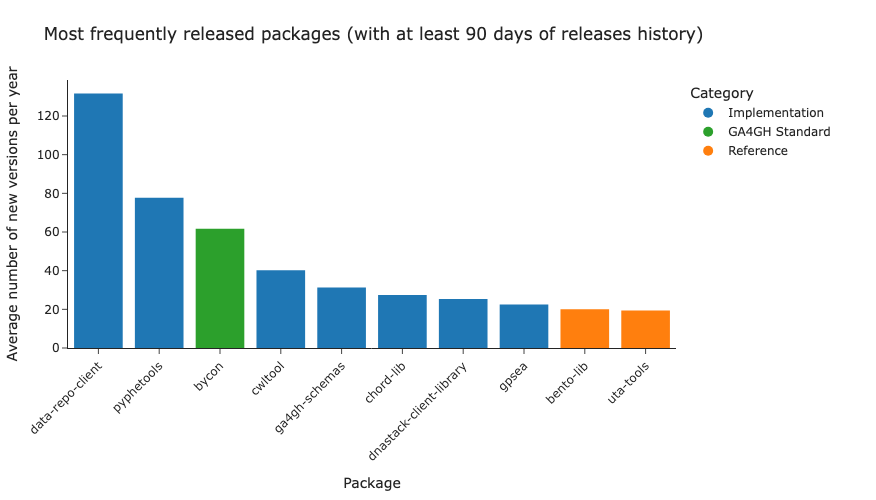

In [252]:
def plot_pypi_frequency():
    
    df = (
        pypi_release_range_df[pypi_release_range_df["range_days"] > 90]
        .sort_values("frequency_year", ascending=False)
        .head(10)
        .copy()
    )

    color_map = {
        "Implementation": "#1f77b4",
        "GA4GH Standard": "#2ca02c",
        "Reference": "#ff7f0e",
    }

    colors = df["category"].map(color_map).fillna("#7f7f7f").tolist()

    fig = px.bar(
        df,
        x="package",
        y="frequency_year",
        labels={"frequency_year": "Average number of new versions per year", "package": "Package"},
        title="Most frequently released packages (with at least 90 days of releases history)",
        custom_data=["count", "first", "last"],
    )

    fig.update_traces(
        marker_color=colors,
        hovertemplate="%{customdata[0]} versions between %{customdata[1]} and %{customdata[2]}<extra></extra>",
        marker_line_width=0,
    )

    used_cats = [c for c in ["Implementation", "GA4GH Standard", "Reference"] if c in df["category"].unique()]
    for cat in used_cats:
        fig.add_trace(
            go.Scatter(
                x=[None],
                y=[None],
                mode="markers",
                marker=dict(size=10, color=color_map.get(cat, "#7f7f7f")),
                name=cat,
                showlegend=True,
            )
        )

    fig.update_layout(
        barmode="relative",
        xaxis_tickangle=-45,
        margin=dict(l=40, r=200, t=80, b=150),  # room for legend on right
        xaxis_title="Package",
        yaxis_title="Average number of new versions per year",
        legend_title_text="Category",
        legend=dict(orientation="v", x=1.02, y=1),
        height=500,
        template="simple_white",
    )

    fig.show()
    
plot_pypi_frequency()

Most recently released packages (new version)

In [61]:
pypi_release_range_df.sort_values('last',ascending=False).head(10)

,package,first,last,count,range_days,frequency_year
15,data-repo-client,2020-12-08,2025-10-03,635,1760,131.690341
48,nmdc-runtime,2021-08-23,2025-10-03,44,1502,10.692410
67,simple-job-files,2022-10-12,2025-10-03,3,1086,1.008287
14,cwltool,2014-11-18,2025-09-25,437,3964,40.238396
60,rarelink,2025-08-08,2025-09-25,3,47,23.297872
51,phenopackets,2021-11-09,2025-09-09,6,1400,1.564286
4,bento-lib,2020-06-11,2025-09-02,105,1909,20.075956
53,planemo,2015-02-16,2025-08-18,148,3836,14.082377
62,refget,2020-06-25,2025-08-13,13,1875,2.530667
61,rd-cdm,2025-08-07,2025-08-08,2,0,inf


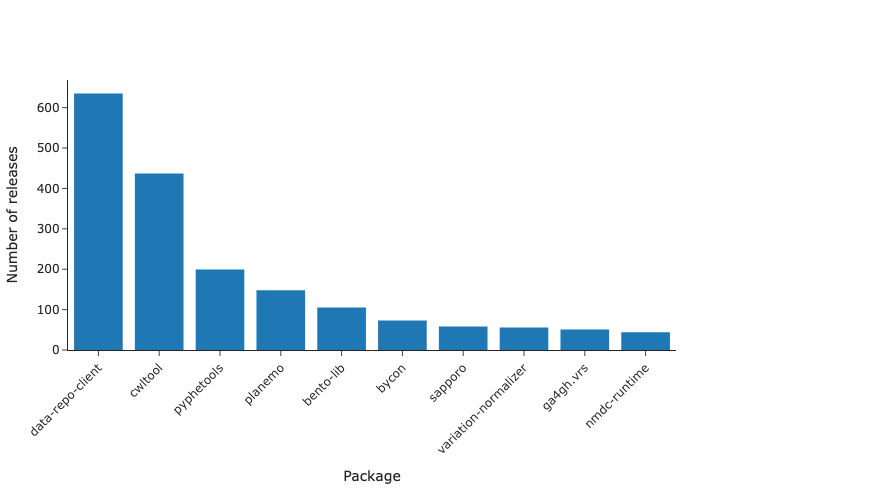

In [264]:
def plot_pypi_versions():
    import plotly.graph_objects as go

    df = pypi_release_range_df.sort_values('count', ascending=False).head(10).reset_index(drop=True)

    customdata = df[["count", "first", "last"]].values

    fig = go.Figure(
        go.Bar(
            x=df["package"],
            y=df["count"],
            #orientation="h",
            customdata=customdata,
            hovertemplate="%{customdata[0]} versions between %{customdata[1]} and %{customdata[2]}<extra></extra>",
            marker_line_width=0,
        )
    )

    fig.update_layout(
        barmode="relative",
        margin=dict(l=40, r=200, t=80, b=150),
        xaxis_tickangle=-45,
        xaxis_title="Package",
        yaxis_title="Number of releases",
        legend_title_text="",
        height=500,
        template="simple_white",
    )

    fig.show()

plot_pypi_versions()

In [69]:
list(pypi_df)

['project_name',
 'description',
 'package_url',
 'release_url',
 'github_url',
 'author_name',
 'author_email',
 'category',
 'versions',
 'id',
 'version',
 'release_date',
 'first_release']

In [71]:
from IPython.display import display, HTML
total_packages = len(pypi_df)
# Convert DataFrame to HTML with DataTables
col_to_show = ['project_name','description',
               'author_name','author_email','category']

html_str = pypi_df[col_to_show].to_html(classes="display", table_id="my_table", index=False)
html_template = f"""
<h3>Total PyPI Packages: {total_packages}</h3>
{html_str}
<link rel="stylesheet" type="text/css" href="https://cdn.datatables.net/1.13.6/css/jquery.dataTables.css">
<script type="text/javascript" charset="utf8" src="https://code.jquery.com/jquery-3.7.1.js"></script>
<script type="text/javascript" charset="utf8" src="https://cdn.datatables.net/1.13.6/js/jquery.dataTables.js"></script>
<script>
$(document).ready(function() {{
    $('#my_table').DataTable({{
        "pageLength": 10,
        "lengthMenu": [5, 10, 20, 50],
        "order": [[0, "asc"]],
        "searching": true,
        "info": true,
        "paging": true
    }});
}});
</script>
"""
# Display inline in notebook
display(HTML(html_template))


project_name,description,author_name,author_email,category
data-repo-client,Data Repository API,OpenAPI Generator community,team@openapitools.org,Implementation
cwltool,Common workflow language reference implementation,Common workflow language working group,common-workflow-language@googlegroups.com,Implementation
pyphetools,Generate and work with GA4GH phenopackets,None,"Peter Robinson <peter.robinson@bih-charite.de>, Daniel Danis <daniel.gordon.danis@protonmail.com>",Implementation
planemo,Command-line utilities to assist in building tools for the Galaxy project (http://galaxyproject.org/).,None,Galaxy Project and Community <galaxy-committers@lists.galaxyproject.org>,Implementation
bento-lib,A set of common utilities and helpers for Bento platform services.,David Lougheed,david.lougheed@mail.mcgill.ca,Reference
bycon,A Python-based environment for the GA4GH Beacon genomics API,None,Michael Baudis <m@baud.is>,GA4GH Standard
sapporo,The sapporo-service is a standard implementation conforming to the Global Alliance for Genomics and Health (GA4GH) Workflow Execution Service (WES) API specification.,None,"""DDBJ (Bioinfomatics and DDBJ Center)"" <tazro.ohta@chiba-u.jp>",Implementation
variation-normalizer,VICC normalization routine for variations,"Alex Wagner, Kori Kuzma, James Stevenson",None,Implementation
ga4gh.vrs,GA4GH Variation Representation Specification (VRS) reference implementation,None,"Larry Babb <lbabb@broadinstitute.org>, Reece Hart <reecehart@gmail.com>, Andreas Prlic <andreas.prlic@gmail.com>, Alex Wagner <alex.wagner@nationwidechildrens.org>",GA4GH Standard
nmdc-runtime,A runtime system for NMDC data management and orchestration,None,None,Reference
